In [215]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from linearmodels.panel import PanelOLS, compare
from linearmodels.panel import RandomEffects
import statsmodels.api as sm
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: '%.4f' % x)


In [229]:
# Load the Excel file
df = pd.read_excel('output.xlsx', sheet_name='Sheet1')

# View column names to identify key variables
print("Column names:")
print(df.columns.tolist())

# Create a panel identifier
df['city_id'] = df['城市']
df['year'] = df['年份']

# Select key variables for analysis
# Based on your dataset structure, identify relevant columns:
# - 房价指数: column 'housing price index' (you need to locate this)
# - 财政缺口: column 'Fiscal Gap' (already computed at the end)

# Let's identify the housing price index column first
# Based on your previous discussion, the housing price index is at the end
# You might need to adjust the column names based on your actual data

# For demonstration, I'll assume:
# - 'housing price index' column contains the 2015-based fixed index
# - 'Fiscal Gap' column is already computed

# If the column names are different, adjust accordingly
df_analysis = df[['city_id', 'year', 
                   '地区生产总值(万元)', '人均地区生产总值(元)', 
                   '常住人口(万人)', '常住人口城镇化率(%)',
                   '地方财政一般预算内收入(万元)', 
                   '地方财政一般预算内支出(万元)', 'housing price index',
                   'Fiscal Gap']].copy()


# Create derived variables
df_analysis['gdp_per_capita_log'] = np.log(df_analysis['人均地区生产总值(元)'])
df_analysis['population_log'] = np.log(df_analysis['常住人口(万人)'])
df_analysis['urbanization'] = df_analysis['常住人口城镇化率(%)'] / 100
df_analysis['fiscal_gap'] = df_analysis['Fiscal Gap']



# Create panel MultiIndex
df_panel = df_analysis.set_index(['city_id', 'year']).sort_index()

print(f"\nPanel data shape: {df_panel.shape}")
print(f"Number of cities: {df_panel.index.get_level_values('city_id').nunique()}")
print(f"Year range: {df_panel.index.get_level_values('year').min()} - {df_panel.index.get_level_values('year').max()}")

Column names:
['年份', '省份', '城市', '省份代码', '城市代码', '所属地域', '胡焕庸线', '地区生产总值(万元)', '第一产业增加值(万元)', '第二产业增加值(万元)', '第三产业增加值(万元)', '第一产业增加值占GDP比重(%)', '第二产业增加值占GDP比重(%)', '第三产业增加值占GDP比重(%)', '人均地区生产总值(元)', '户籍人口(万人)', '城镇户籍人口(万人)', '非农业人口数(万人)', '年平均人口(万人)', '年末总户数(万户)', '出生人口(人)', '死亡人口(人)', '自然增长率(‰)', '常住人口(万人)', '城镇常住人口(万人)', '常住人口城镇化率(%)', '城镇非私营单位从业人员数(万人)', '城镇私营和个体从业人员数(人)', '年末城镇登记失业人员数(人)', '第一产业从业人员数(万人)', '第二产业从业人员数(万人)', '第三产业从业人员数(万人)', '第一产业从业人员比重(%)', '第二产业从业人员比重(%)', '第三产业从业人员比重(%)', '农林牧渔业从业人员数(万人)', '采掘业从业人员数(万人)', '制造业从业人员数(万人)', '电力煤气及水生产供应业从业人员数(万人)', '建筑业从业人员数(万人)', '交通仓储邮电业从业人员数(万人)', '信息传输、计算机服务和软件业从业人员数(万人)', '批发零售贸易业从业人员数(万人)', '住宿餐饮业从业人员数(万人)', '金融业从业人员数(万人)', '房地产业从业人员数(万人)', '租赁和商业服务业从业人员数(万人)', '科研、技术服务和地质勘查业从业人员数(万人)', '水利、环境和公共设施管理业从业人员数(万人)', '居民服务和其他服务业从业人员数(万人)', '教育业从业人员数(万人)', '卫生、社会保险和社会福利业从业人员数(万人)', '文化、体育和娱乐业从业人员数(万人)', '公共管理和社会组织从业人员数(万人)', '地质勘察水利管理业从业人数(万人)', '交通仓储邮电通信业从业人员数(万人)', '批发零售贸易餐饮业从业人员数(万人)', '社会服务业从业人员数(万人)', '卫生体育社会福利业从业人员数(万人)', '教育文艺广

In [187]:
df_analysis

,city_id,year,地区生产总值(万元),人均地区生产总值(元),常住人口(万人),常住人口城镇化率(%),地方财政一般预算内收入(万元),地方财政一般预算内支出(万元),housing price index,Fiscal Gap,gdp_per_capita_log,population_log,urbanization,fiscal_gap
0,北京市,2011,162519300,81658,NaN,NaN,30062751,32452264,93.3000,-0.0147,11.3103,NaN,NaN,-0.0147
1,北京市,2012,178794000,87475,NaN,NaN,33149340,36853076,94.9000,-0.0207,11.3791,NaN,NaN,-0.0207
2,北京市,2013,195005600,93213,NaN,NaN,36611097,41736563,111.0000,-0.0263,11.4426,NaN,NaN,-0.0263
3,北京市,2014,213308300,99995,NaN,NaN,40271609,45246690,115.2000,-0.0233,11.5129,NaN,NaN,-0.0233
4,北京市,2015,230145900,106497,NaN,NaN,47238597,57377011,100.0000,-0.0441,11.5759,NaN,NaN,-0.0441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
961,乌鲁木齐市,2020,33370000,82314,405.0000,NaN,3926378,5368738,110.9000,-0.0432,11.3183,6.0039,NaN,-0.0432
962,乌鲁木齐市,2021,36920000,90794,406.0000,NaN,3779260,4195874,110.1000,-0.0113,11.4163,6.0064,NaN,-0.0113
963,乌鲁木齐市,2022,38930000,95559,407.0000,NaN,3148203,4557678,103.7000,-0.0362,11.4675,6.0088,NaN,-0.0362
964,乌鲁木齐市,2023,41680000,102078,408.0000,96.5600,3697888,5040517,101.6000,-0.0322,11.5335,6.0113,0.9656,-0.0322


In [191]:
import numpy as np
import pandas as pd

# ---------- choose variables you want in the table ----------
vars_main = [
    "housing price index",
    "fiscal_gap",
    "gdp_per_capita_log",
    "population_log",
    "urbanization",
]

# keep only those that actually exist
vars_main = [v for v in vars_main if v in df_panel.columns]

# ---------- overall summary ----------
summary_overall = (df_panel[vars_main]
                   .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
                   .T
                   .rename(columns={"50%": "median"}))

# Add missing share
summary_overall["missing_share"] = df_panel[vars_main].isna().mean().values

# Reorder columns nicely
cols_order = ["count", "mean", "std", "min", "1%", "5%", "25%", "median", "75%", "95%", "99%", "max", "missing_share"]
summary_overall = summary_overall[[c for c in cols_order if c in summary_overall.columns]]

print("Overall summary statistics:")
print(summary_overall)

# ---------- by city (within-city averages; each city gets one row) ----------
city_means = df_panel[vars_main].groupby(level=0).mean(numeric_only=True)
summary_city_means = (city_means
                      .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
                      .T
                      .rename(columns={"50%": "median"}))

print("\nSummary of city-level means (distribution across cities):")
print(summary_city_means)

# ---------- by year (national distribution over time; one row per year) ----------
year_means = df_panel[vars_main].groupby(level=1).mean(numeric_only=True)
print("\nYear-by-year means (time series table):")
print(year_means)

# Optional: save
summary_overall.to_csv("summary_overall.csv", encoding="utf-8-sig")
summary_city_means.to_csv("summary_city_means.csv", encoding="utf-8-sig")
year_means.to_csv("year_means.csv", encoding="utf-8-sig")

Overall summary statistics:
                       count     mean     std     min      1%      5%     25%  \
housing price index 966.0000 107.4111 11.6024 88.5000 90.8300 94.1250 98.3000   
fiscal_gap          966.0000  -0.0671  0.0498 -0.2867 -0.2143 -0.1679 -0.0934   
gdp_per_capita_log  966.0000  11.1844  0.4930  9.6738  9.9942 10.3642 10.8448   
population_log      345.0000   6.4830  0.6532  4.6444  4.7095  5.4134  6.0544   
urbanization        138.0000   0.7395  0.1148  0.4807  0.5016  0.5538  0.6538   

                      median      75%      95%      99%      max  \
housing price index 106.0000 113.7000 129.4500 140.3050 170.0000   
fiscal_gap           -0.0549  -0.0304  -0.0078   0.0022   0.0671   
gdp_per_capita_log   11.2159  11.5321  11.9676  12.1622  12.3378   
population_log        6.5596   6.8648   7.6601   8.0680   8.0737   
urbanization          0.7305   0.8347   0.8970   0.9876   0.9980   

                     missing_share  
housing price index         0.0000  
fi

In [193]:
import os, re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

FILE = "CCCH9007data.xlsx"
SHEET = "Sheet5"
OUT_DIR = "figures"
os.makedirs(OUT_DIR, exist_ok=True)

# -----------------------------
# Helpers
# -----------------------------
def clean_col(c: str) -> str:
    return re.sub(r"\s+", "", str(c)).strip()

def find_col_by_keywords(columns, keywords, must_all=False):
    cols = list(columns)
    cols_clean = {c: clean_col(c) for c in cols}
    for c, cc in cols_clean.items():
        hits = [re.search(k, cc, flags=re.IGNORECASE) is not None for k in keywords]
        if (all(hits) if must_all else any(hits)):
            return c
    return None

def to_num(s):
    return pd.to_numeric(s, errors="coerce")

def savefig(fname):
    path = os.path.join(OUT_DIR, fname)
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.close()
    print("Saved:", path)

# -----------------------------
# Load & standardize
# -----------------------------
df = pd.read_excel(FILE, sheet_name=SHEET)
df.columns = [clean_col(c) for c in df.columns]

year_col  = find_col_by_keywords(df.columns, [r"^年份$|^year$"])
city_col  = find_col_by_keywords(df.columns, [r"^城市$|^city$"])
prov_col  = find_col_by_keywords(df.columns, [r"^省份$|^province$"])
region_col = find_col_by_keywords(df.columns, [r"所属地域|地区|region"])
large_col = find_col_by_keywords(df.columns, [r"largecity|large_city|大城市|^large$"])

# Key vars (try match; adjust keywords if your header differs)
land_sale_col = find_col_by_keywords(df.columns, [r"土地出让收入|国有土地使用权出让收入|土地出让金|出让收入|土地出让"])
sales_area_col = find_col_by_keywords(df.columns, [r"商品房销售面积|房屋销售面积|销售面积"])
re_invest_col = find_col_by_keywords(df.columns, [r"房地产开发投资完成额|房地产投资"])
sales_value_col = find_col_by_keywords(df.columns, [r"商品房销售额|房屋销售额|销售额"])

# For dependence + fiscal pressure
rev_col = find_col_by_keywords(df.columns, [r"地方财政一般预算内收入"])
exp_col = find_col_by_keywords(df.columns, [r"地方财政一般预算内支出"])
fisc_gap_col = find_col_by_keywords(df.columns, [r"FiscalGap|Fiscal\s*Gap|财政缺口"])

# Housing price index / other outcomes
hpi_col = find_col_by_keywords(df.columns, [r"housingpriceindex|housing\s*price\s*index|房价指数"])
inventory_col = find_col_by_keywords(df.columns, [r"库存|待售面积|可售面积|去化|存量"])  # may not exist

print("Matched columns:")
for k, v in {
    "year": year_col, "city": city_col, "province": prov_col, "region": region_col, "large": large_col,
    "land_sale": land_sale_col, "sales_area": sales_area_col, "sales_value": sales_value_col,
    "re_invest": re_invest_col, "rev": rev_col, "exp": exp_col, "fiscal_gap": fisc_gap_col,
    "hpi": hpi_col, "inventory": inventory_col
}.items():
    print(f"  {k:>12}: {v}")

need_base = [year_col, city_col]
if any(c is None for c in need_base):
    raise ValueError("Missing required columns: 年份 and 城市 (or year/city).")

# numeric coercion
for c in [year_col, land_sale_col, sales_area_col, re_invest_col, sales_value_col,
          rev_col, exp_col, fisc_gap_col, hpi_col, inventory_col, large_col]:
    if c and c in df.columns:
        df[c] = to_num(df[c])

df = df.dropna(subset=[year_col, city_col]).copy()
df[year_col] = df[year_col].astype(int)

# -----------------------------
# Derived variables
# -----------------------------
# Fiscal gap (if not present, calculate = exp - rev)
if (not fisc_gap_col) and (rev_col and exp_col):
    df["FiscalGap_calc"] = df[exp_col] - df[rev_col]
    fisc_gap_col = "FiscalGap_calc"

# Land-finance dependence = land sale / fiscal revenue
if land_sale_col and rev_col:
    df["land_finance_dependence"] = df[land_sale_col] / df[rev_col]

# If you want a fiscal pressure proxy (use fiscal gap level by default)
if fisc_gap_col:
    df["fiscal_pressure"] = df[fisc_gap_col]

# Population (for your “人口变化”对比图，若表里有)
pop_col = find_col_by_keywords(df.columns, [r"常住人口"])
if pop_col:
    df[pop_col] = to_num(df[pop_col])

# -----------------------------
# Plot theme
# -----------------------------
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "SimHei", "Noto Sans CJK SC", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# ============================================================
# 1) 折线图：全国土地出让收入、房屋销售面积、房地产投资（按年汇总）
# ============================================================
series_map = {
    "Land sale revenue": land_sale_col,
    "Housing sales area": sales_area_col,
    "Real estate investment": re_invest_col,
}

trend = pd.DataFrame(index=sorted(df[year_col].unique()))
ok = False
for label, col in series_map.items():
    if col and col in df.columns:
        # sum across cities (flow variables)
        trend[label] = df.groupby(year_col)[col].sum(min_count=1)
        ok = True
    else:
        print(f"[WARN] Missing trend variable: {label} (matched={col})")

if ok:
    plt.figure(figsize=(10, 6))
    for label in trend.columns:
        plt.plot(trend.index, trend[label], marker="o", linewidth=2, label=label)
    plt.title("National trends (sum across cities)")
    plt.xlabel("Year")
    plt.ylabel("Value (original units)")
    plt.legend()
    savefig("line_national_trends_sum.png")

    # Optional indexed plot (base year = first year)
    base_year = trend.index.min()
    trend_idx = trend / trend.loc[base_year] * 100
    plt.figure(figsize=(10, 6))
    for label in trend_idx.columns:
        plt.plot(trend_idx.index, trend_idx[label], marker="o", linewidth=2, label=label)
    plt.title(f"National trends index ({base_year}=100)")
    plt.xlabel("Year")
    plt.ylabel("Index")
    plt.legend()
    savefig("line_national_trends_index.png")
else:
    print("[WARN] No national trend plot generated (all three series missing).")

# ============================================================
# 2) 柱状图：不同地区或不同城市的财政依赖程度
#    财政依赖程度 = land_sale / fiscal revenue（若可算）
# ============================================================
if "land_finance_dependence" in df.columns:
    latest_year = int(df[year_col].max())
    latest = df[df[year_col] == latest_year].copy()

    # 2a) by region (mean across cities)
    if region_col and region_col in df.columns:
        tmp = latest[[region_col, "land_finance_dependence"]].dropna()
        by_region = tmp.groupby(region_col)["land_finance_dependence"].mean().sort_values(ascending=False)

        plt.figure(figsize=(10, 5))
        sns.barplot(x=by_region.index, y=by_region.values, color="#4C72B0")
        plt.title(f"Land-finance dependence by region (mean), {latest_year}")
        plt.xlabel("Region")
        plt.ylabel("Land sale / fiscal revenue")
        plt.xticks(rotation=20, ha="right")
        savefig("bar_land_dependence_by_region_latest.png")
    else:
        print("[WARN] Region column not found; skip region bar plot.")

    # 2b) top-20 cities bar
    tmp = latest[[city_col, "land_finance_dependence"]].dropna().sort_values("land_finance_dependence", ascending=False).head(20)
    if len(tmp) > 0:
        plt.figure(figsize=(10, 6))
        sns.barplot(data=tmp, y=city_col, x="land_finance_dependence", color="#55A868")
        plt.title(f"Top 20 cities: land-finance dependence, {latest_year}")
        plt.xlabel("Land sale / fiscal revenue")
        plt.ylabel("City")
        savefig("bar_top20_cities_land_dependence_latest.png")
else:
    print("[WARN] Cannot draw dependence bars: need land sale revenue and fiscal revenue columns.")

# ============================================================
# 3) 散点图：land-finance dependence 与财政压力（Fiscal Gap 等）关系
# ============================================================
if ("land_finance_dependence" in df.columns) and ("fiscal_pressure" in df.columns):
    data_sc = df[["land_finance_dependence", "fiscal_pressure", year_col]].dropna()

    # 3a) pooled scatter + regression line
    plt.figure(figsize=(7.5, 5.5))
    sns.scatterplot(data=data_sc, x="land_finance_dependence", y="fiscal_pressure", alpha=0.5, edgecolor=None)
    sns.regplot(data=data_sc, x="land_finance_dependence", y="fiscal_pressure",
                scatter=False, color="black", line_kws={"linewidth": 2})
    plt.title("Land-finance dependence vs fiscal pressure (pooled)")
    plt.xlabel("Land sale / fiscal revenue")
    plt.ylabel("Fiscal pressure (e.g., Fiscal Gap)")
    savefig("scatter_land_dependence_vs_fiscal_pressure.png")

    # 3b) colored by year (optional, can be busy)
    # Uncomment if you want:
    # plt.figure(figsize=(8, 6))
    # sns.scatterplot(data=data_sc, x="land_finance_dependence", y="fiscal_pressure",
    #                 hue=year_col, palette="viridis", alpha=0.6, edgecolor=None)
    # plt.title("Land-finance dependence vs fiscal pressure (colored by year)")
    # plt.xlabel("Land sale / fiscal revenue")
    # plt.ylabel("Fiscal pressure")
    # plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    # savefig("scatter_land_dependence_vs_fiscal_pressure_by_year.png")
else:
    print("[WARN] Cannot draw scatter: need land_finance_dependence and fiscal pressure (Fiscal Gap).")

# ============================================================
# 4) 对比图：大城市 vs 小城市（房价、销量、库存、人口变化）
#    - 折线：按 large city 分组的年度均值
# ============================================================
if large_col and large_col in df.columns:
    # Ensure it's 0/1-ish
    tmp_large = df[[large_col]].dropna()
    # if it is coded as strings etc., you might need to map; here we just proceed.

    compare_candidates = [
        ("House price index", hpi_col, "mean"),
        ("Sales area", sales_area_col, "mean"),
        ("Inventory", inventory_col, "mean"),
        ("Population", pop_col, "mean"),
    ]

    for label, col, agg in compare_candidates:
        if col and col in df.columns:
            grp = (df.groupby([year_col, large_col])[col]
                   .mean()
                   .reset_index())

            plt.figure(figsize=(10, 5))
            sns.lineplot(data=grp, x=year_col, y=col, hue=large_col, marker="o")
            plt.title(f"{label}: large vs small cities (mean across cities)")
            plt.xlabel("Year")
            plt.ylabel(label)
            plt.legend(title="large city (0=small, 1=large)")
            savefig(f"line_large_vs_small_{clean_col(label).lower()}.png")
        else:
            print(f"[WARN] Missing for large-vs-small: {label} (matched={col})")

    # Optional: last-year boxplots (distribution comparison)
    latest_year = int(df[year_col].max())
    for label, col, _ in compare_candidates:
        if col and col in df.columns:
            tmp = df[df[year_col] == latest_year][[large_col, col]].dropna()
            if len(tmp) > 0:
                plt.figure(figsize=(7, 5))
                sns.boxplot(data=tmp, x=large_col, y=col)
                plt.title(f"{label} distribution by city size, {latest_year}")
                plt.xlabel("large city (0=small, 1=large)")
                plt.ylabel(label)
                savefig(f"box_large_vs_small_{clean_col(label).lower()}_{latest_year}.png")
else:
    print("[WARN] large city flag not found; skip large vs small comparisons.")

print("\nDone. All figures saved to:", OUT_DIR)

Matched columns:
          year: 年份
          city: 城市
      province: 省份
        region: 所属地域
         large: largecity
     land_sale: None
    sales_area: None
   sales_value: None
     re_invest: 房地产开发投资完成额(万元)
           rev: 地方财政一般预算内收入(万元)
           exp: 地方财政一般预算内支出(万元)
    fiscal_gap: FiscalGap
           hpi: housingpriceindexinhundreds
     inventory: None
[WARN] Missing trend variable: Land sale revenue (matched=None)
[WARN] Missing trend variable: Housing sales area (matched=None)
Saved: figures/line_national_trends_sum.png
Saved: figures/line_national_trends_index.png
[WARN] Cannot draw dependence bars: need land sale revenue and fiscal revenue columns.
[WARN] Cannot draw scatter: need land_finance_dependence and fiscal pressure (Fiscal Gap).
Saved: figures/line_large_vs_small_housepriceindex.png
[WARN] Missing for large-vs-small: Sales area (matched=None)
[WARN] Missing for large-vs-small: Inventory (matched=None)
Saved: figures/line_large_vs_small_population.png
Saved: 


=== Descriptive Statistics ===
       fiscal_gap  gdp_per_capita_log  population_log  urbanization
count    966.0000            966.0000        345.0000      138.0000
mean      -0.0671             11.1844          6.4830        0.7395
std        0.0498              0.4930          0.6532        0.1148
min       -0.2867              9.6738          4.6444        0.4807
25%       -0.0934             10.8448          6.0544        0.6538
50%       -0.0549             11.2159          6.5596        0.7305
75%       -0.0304             11.5321          6.8648        0.8347
max        0.0671             12.3378          8.0737        0.9980


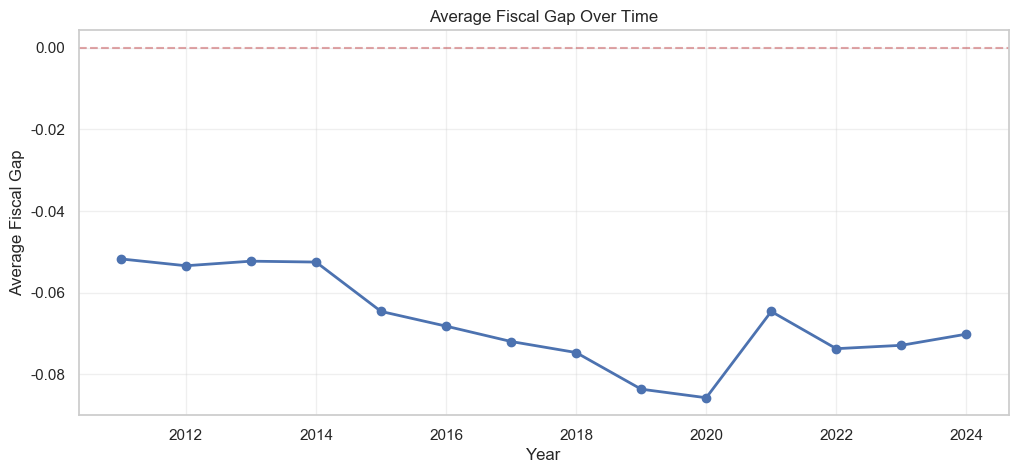

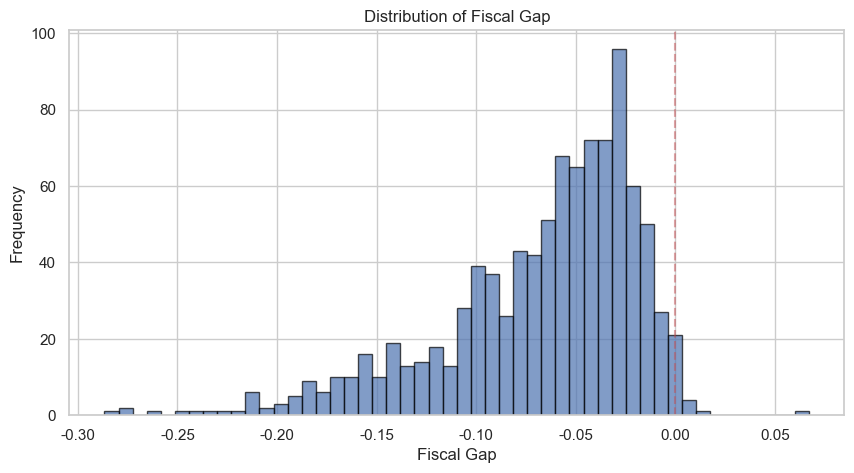

In [194]:
# Summary statistics
desc_stats = df_panel[['fiscal_gap', 'gdp_per_capita_log', 'population_log', 
                        'urbanization']].describe()
print("\n=== Descriptive Statistics ===")
print(desc_stats)

# Time series plot of average fiscal gap by year
yearly_avg = df_panel.groupby('year')['fiscal_gap'].mean().reset_index()
plt.figure(figsize=(12, 5))
plt.plot(yearly_avg['year'], yearly_avg['fiscal_gap'], marker='o', linewidth=2)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.xlabel('Year')
plt.ylabel('Average Fiscal Gap')
plt.title('Average Fiscal Gap Over Time')
plt.grid(True, alpha=0.3)
plt.show()

# Histogram of fiscal gap
plt.figure(figsize=(10, 5))
plt.hist(df_panel['fiscal_gap'].dropna(), bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Fiscal Gap')
plt.ylabel('Frequency')
plt.title('Distribution of Fiscal Gap')
plt.axvline(x=0, color='r', linestyle='--', alpha=0.5)
plt.show()

In [262]:
# Panel FE regressions for:
# (1) housing weakness -> fiscal constraints
# (2) fiscal constraints -> housing outcomes
#
# Required packages:
# pip install pandas numpy linearmodels statsmodels openpyxl

import pandas as pd
import numpy as np
from linearmodels.panel import PanelOLS

# =========================================================
# 1. Load data
# =========================================================

# Replace with your file path
FILE_PATH = "output2.xlsx"

df = pd.read_excel(FILE_PATH)

# =========================================================
# 2. Rename columns
#    Edit these names to match your dataset exactly
# =========================================================

rename_map = {
    "年份": "year",
    "城市代码": "city_code",
    "省份代码": "prov_code",
    "城市": "city",
    "省份": "province",

    "地区生产总值(万元)": "gdp",
    "地区生产总值增长率(%)": "gdp_growth",
    "常住人口(万人)": "population",
    "常住人口城镇化率(%)": "urban_rate",
    "年末金融机构各项贷款余额(万元)": "loans",
    "房地产开发投资完成额(万元)": "re_invest",
    "地方财政一般预算内收入(万元)": "fiscal_revenue",
    "地方财政一般预算内支出(万元)": "fiscal_expenditure",
    "城镇非私营单位在岗职工平均工资(元)": "avg_wage",
    "年末城镇登记失业人员数(人)": "unemployment",

    # already included in your data list
    "Fiscal Gap": "fiscal_gap",
    "housing price index": "house_price_index",

    # optional variables if available
    # "商品房销售面积(万平方米)": "housing_sales_area",
    # "商品房销售额(万元)": "housing_sales_value",
    # "住宅用地供应面积(公顷)": "land_supply"
}

df = df.rename(columns=rename_map)

# =========================================================
# 3. Keep core variables
# =========================================================

core_vars = [
    "year", "city_code", "prov_code", "city", "province",
    "gdp", "gdp_growth", "population", "urban_rate", "loans",
    "re_invest", "fiscal_revenue", "fiscal_expenditure",
    "avg_wage", "unemployment", "fiscal_gap", "house_price_index"
]

# keep optional vars only if present
optional_vars = [c for c in ["housing_sales_area", "housing_sales_value", "land_supply"] if c in df.columns]
keep_vars = [c for c in core_vars if c in df.columns] + optional_vars
df = df[keep_vars].copy()

# =========================================================
# 4. Basic cleaning
# =========================================================

# Drop rows without panel identifiers
df = df.dropna(subset=["year", "city_code"])

# Convert year to int if possible
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df.dropna(subset=["year"])
df["year"] = df["year"].astype(int)

# Convert all non-ID numeric variables to numeric
id_like = {"year", "city_code", "prov_code", "city", "province"}
for col in df.columns:
    if col not in id_like:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Sort panel
df = df.sort_values(["city_code", "year"]).reset_index(drop=True)

# =========================================================
# 5. Construct variables
# =========================================================

# If fiscal_gap is not reliable / missing, reconstruct it
if "fiscal_gap" not in df.columns or df["fiscal_gap"].isna().all():
    df["fiscal_gap"] = df["fiscal_expenditure"] - df["fiscal_revenue"]

# Normalized fiscal gap
df["fiscal_gap_gdp"] = df["fiscal_gap"] / df["gdp"]
df["fiscal_gap_rev"] = df["fiscal_gap"] / df["fiscal_revenue"]

# Logs
for v in ["gdp", "population", "loans", "re_invest", "avg_wage"]:
    if v in df.columns:
        df[f"log_{v}"] = np.log(df[v].replace({0: np.nan}))

# Unemployment log(1+x)
if "unemployment" in df.columns:
    df["log_unemployment"] = np.log1p(df["unemployment"])

# Housing price growth and weakness
# weakness = negative of price growth, so higher means weaker market
df["log_hpi"] = np.log(df["house_price_index"].replace({0: np.nan}))
df["hpi_growth"] = df.groupby("city_code")["log_hpi"].diff()
df["housing_weakness"] = -df["hpi_growth"]

# Optional sales growth if available
if "housing_sales_area" in df.columns:
    df["log_sales_area"] = np.log(df["housing_sales_area"].replace({0: np.nan}))
    df["sales_area_growth"] = df.groupby("city_code")["log_sales_area"].diff()

if "housing_sales_value" in df.columns:
    df["log_sales_value"] = np.log(df["housing_sales_value"].replace({0: np.nan}))
    df["sales_value_growth"] = df.groupby("city_code")["log_sales_value"].diff()

if "land_supply" in df.columns:
    df["log_land_supply"] = np.log(df["land_supply"].replace({0: np.nan}))

# Lags
df["L1_housing_weakness"] = df.groupby("city_code")["housing_weakness"].shift(1)
df["L1_fiscal_gap_gdp"] = df.groupby("city_code")["fiscal_gap_gdp"].shift(1)
df["L1_fiscal_gap_rev"] = df.groupby("city_code")["fiscal_gap_rev"].shift(1)

threshold = 0.9
df = df.dropna(axis=1, thresh=int(threshold * len(df)))

df

,year,city_code,prov_code,city,province,gdp,gdp_growth,loans,fiscal_revenue,fiscal_expenditure,fiscal_gap,house_price_index,fiscal_gap_gdp,fiscal_gap_rev,log_gdp,log_loans,log_hpi,hpi_growth,housing_weakness,L1_fiscal_gap_gdp,L1_fiscal_gap_rev
0,2011,110000,110000,北京市,北京市,162519300,8.1000,317912891,30062751,32452264,-0.0147,93.3000,-0.0000,-0.0000,18.9063,19.5773,4.5358,NaN,NaN,NaN,NaN
1,2012,110000,110000,北京市,北京市,178794000,7.7300,345179846,33149340,36853076,-0.0207,94.9000,-0.0000,-0.0000,19.0017,19.6596,4.5528,0.0170,-0.0170,-0.0000,-0.0000
2,2013,110000,110000,北京市,北京市,195005600,9.0700,382214492,36611097,41736563,-0.0263,111.0000,-0.0000,-0.0000,19.0885,19.7615,4.7095,0.1567,-0.1567,-0.0000,-0.0000
3,2014,110000,110000,北京市,北京市,213308300,7.3000,424452990,40271609,45246690,-0.0233,115.2000,-0.0000,-0.0000,19.1782,19.8663,4.7467,0.0371,-0.0371,-0.0000,-0.0000
4,2015,110000,110000,北京市,北京市,230145900,6.9000,488531687,47238597,57377011,-0.0441,100.0000,-0.0000,-0.0000,19.2542,20.0069,4.6052,-0.1415,0.1415,-0.0000,-0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
961,2020,650100,650000,乌鲁木齐市,新疆维吾尔自治区,33370000,0.3000,86721139,3926378,5368738,-0.0432,110.9000,-0.0000,-0.0000,17.3232,18.2782,4.7086,-0.1348,0.1348,-0.0000,-0.0000
962,2021,650100,650000,乌鲁木齐市,新疆维吾尔自治区,36920000,6.1000,98018089,3779260,4195874,-0.0113,110.1000,-0.0000,-0.0000,17.4243,18.4007,4.7014,-0.0072,0.0072,-0.0000,-0.0000
963,2022,650100,650000,乌鲁木齐市,新疆维吾尔自治区,38930000,0.3000,106029921,3148203,4557678,-0.0362,103.7000,-0.0000,-0.0000,17.4773,18.4792,4.6415,-0.0599,0.0599,-0.0000,-0.0000
964,2023,650100,650000,乌鲁木齐市,新疆维吾尔自治区,41680000,6.0000,116634903,3697888,5040517,-0.0322,101.6000,-0.0000,-0.0000,17.5455,18.5746,4.6210,-0.0205,0.0205,-0.0000,-0.0000


In [277]:
# Model A: Fiscal Gap ~ Housing Market + Controls


if 'housing price index' in df_panel.columns:
    df_panel['housing_market'] = df_panel['housing price index']
else:
    # If not available, use GDP growth as a proxy (not ideal, just for demonstration)
    df_panel['gdp_growth'] = df_panel.groupby('city_id')['地区生产总值(万元)'].pct_change()
    df_panel['housing_market'] = df_panel['gdp_growth']

# Define y and X
y = df_panel['fiscal_gap']
X = df_panel[['housing_market', 'gdp_per_capita_log', 'population_log', 'urbanization']]

# Estimate with entity and time fixed effects
model_A = PanelOLS(y, X, entity_effects=True, time_effects=True)
result_A = model_A.fit(cov_type='clustered', cluster_entity=True)

print(result_A)

df_diff = df_panel.sort_index().groupby('city_id').diff().dropna()
y_diff = df_diff['fiscal_gap']
X_diff = df_diff[['housing_market', 'gdp_per_capita_log', 'population_log', 'urbanization']]

mod_diff = PanelOLS(y_diff, X_diff, entity_effects=False, time_effects=True)
res_diff = mod_diff.fit(cov_type='clustered', cluster_entity=True)
print('---------------------------')
print(res_diff)

                          PanelOLS Estimation Summary                           
Dep. Variable:             fiscal_gap   R-squared:                        0.3114
Estimator:                   PanelOLS   R-squared (Between):             -31.211
No. Observations:                 966   R-squared (Within):              -0.9737
Date:                Sat, Mar 28 2026   R-squared (Overall):             -29.469
Time:                        12:34:52   Log-likelihood                    2754.0
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      99.496
Entities:                          69   P-value                           0.0000
Avg Obs:                       14.000   Distribution:                   F(4,880)
Min Obs:                       14.000                                           
Max Obs:                       14.000   F-statistic (robust):             10.227
                            

In [281]:
# Model B


if 'fiscal_gap' in df_panel.columns:
    df_panel['fiscal_gap'] = df_panel['fiscal_gap']
else:
    # If not available, use GDP growth as a proxy (not ideal, just for demonstration)
    df_panel['gdp_growth'] = df_panel.groupby('city_id')['地区生产总值(万元)'].pct_change()
    df_panel['housing_market'] = df_panel['gdp_growth']

# Define y and X
y2 = df_panel['housing_market']
X2 = df_panel[['fiscal_gap', 'gdp_per_capita_log', 'population_log', 'urbanization']]

# Estimate with entity and time fixed effects
model_B = PanelOLS(y2, X2, entity_effects=True, time_effects=True)
result_B = model_B.fit(cov_type='clustered', cluster_entity=True)

print(result_B)

df_diff2 = df_panel.sort_index().groupby('city_id').diff().dropna()
y_diff2 = df_diff2['housing_market']
X_diff2 = df_diff2[['fiscal_gap', 'gdp_per_capita_log', 'population_log', 'urbanization']]

mod_diff2 = PanelOLS(y_diff2, X_diff2, entity_effects=False, time_effects=True)
res_diff2 = mod_diff2.fit(cov_type='clustered', cluster_entity=True)
print('---------------------------')
print(res_diff2)

                          PanelOLS Estimation Summary                           
Dep. Variable:         housing_market   R-squared:                        0.0300
Estimator:                   PanelOLS   R-squared (Between):             -17.527
No. Observations:                 966   R-squared (Within):               0.0878
Date:                Sat, Mar 28 2026   R-squared (Overall):             -17.338
Time:                        12:38:39   Log-likelihood                   -3102.0
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      6.7964
Entities:                          69   P-value                           0.0000
Avg Obs:                       14.000   Distribution:                   F(4,880)
Min Obs:                       14.000                                           
Max Obs:                       14.000   F-statistic (robust):             6.7361
                            

In [287]:
# Model A: Fiscal Gap ~ Housing Market + Controls


if 'housing price index' in df_panel.columns:
    df_panel['housing_market'] = df_panel['housing price index']
else:
    # If not available, use GDP growth as a proxy (not ideal, just for demonstration)
    df_panel['gdp_growth'] = df_panel.groupby('city_id')['地区生产总值(万元)'].pct_change()
    df_panel['housing_market'] = df_panel['gdp_growth']

# Define formula for Model A
formula_A = 'fiscal_gap ~ housing_market + gdp_per_capita_log + population_log + urbanization + EntityEffects + TimeEffects'

# Estimate with entity and time fixed effects
model_A = PanelOLS.from_formula(formula_A, data=df_panel)

result_A = model_A.fit(cov_type='clustered', cluster_entity=True)

print("\n" + "="*60)
print("MODEL A: Housing Market → Fiscal Constraints")
print("="*60)
print(result_A)

# Extract key results
print("\n=== Key Coefficients ===")
print(f"Housing Market coefficient: {result_A.params['housing_market']:.4f}")
print(f"Standard error: {result_A.std_errors['housing_market']:.4f}")
print(f"P-value: {result_A.pvalues['housing_market']:.4f}")
print(f"Within R-squared: {result_A.rsquared_within:.4f}")


MODEL A: Housing Market → Fiscal Constraints
                          PanelOLS Estimation Summary                           
Dep. Variable:             fiscal_gap   R-squared:                        0.3114
Estimator:                   PanelOLS   R-squared (Between):             -31.211
No. Observations:                 966   R-squared (Within):              -0.9737
Date:                Sat, Mar 28 2026   R-squared (Overall):             -29.469
Time:                        19:43:30   Log-likelihood                    2754.0
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      99.496
Entities:                          69   P-value                           0.0000
Avg Obs:                       14.000   Distribution:                   F(4,880)
Min Obs:                       14.000                                           
Max Obs:                       14.000   F-statistic (robust):  

In [291]:
# Create lagged housing market variable
df_panel['housing_market_lag'] = df_panel.groupby('city_id')['housing_market'].shift(1)

# Drop rows with missing lag values
df_panel_lag = df_panel.dropna(subset=['housing_market_lag'])

# Model with lagged variable
formula_A_lag = 'fiscal_gap ~ housing_market_lag + gdp_per_capita_log + population_log + urbanization + EntityEffects + TimeEffects'
model_A_lag = PanelOLS.from_formula(formula_A_lag, data=df_panel_lag,
                                        )
result_A_lag = model_A_lag.fit(cov_type='clustered', cluster_entity=True)

print("\n" + "="*60)
print("MODEL A with Lagged Housing Market")
print("="*60)
print(result_A_lag)


MODEL A with Lagged Housing Market
                          PanelOLS Estimation Summary                           
Dep. Variable:             fiscal_gap   R-squared:                        0.2931
Estimator:                   PanelOLS   R-squared (Between):             -16.380
No. Observations:                 897   R-squared (Within):              -0.7095
Date:                Sat, Mar 28 2026   R-squared (Overall):             -15.548
Time:                        19:43:39   Log-likelihood                    2562.2
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      84.173
Entities:                          69   P-value                           0.0000
Avg Obs:                       13.000   Distribution:                   F(4,812)
Min Obs:                       13.000                                           
Max Obs:                       13.000   F-statistic (robust):            

In [283]:
# Model B: Housing market ~ Fiscal gap + Controls


if 'housing price index' in df_panel.columns:
    df_panel['housing_market'] = df_panel['housing price index']


# Define formula for Model A
formula_B = ' housing_market ~ fiscal_gap + gdp_per_capita_log + population_log + urbanization + EntityEffects + TimeEffects'

# Estimate with entity and time fixed effects
model_B = PanelOLS.from_formula(formula_B, data=df_panel)

result_B = model_B.fit(cov_type='clustered', cluster_entity=True)

print("\n" + "="*60)
print("MODEL B: Fiscal Constraints → Housing Market")
print("="*60)
print(result_B)

# Extract key results
print("\n=== Key Coefficients ===")
print(f"Housing Market coefficient: {result_B.params['fiscal_gap']:.4f}")
print(f"Standard error: {result_B.std_errors['fiscal_gap']:.4f}")
print(f"P-value: {result_B.pvalues['fiscal_gap']:.4f}")
print(f"Within R-squared: {result_B.rsquared_within:.4f}")


MODEL B: Fiscal Constraints → Housing Market
                          PanelOLS Estimation Summary                           
Dep. Variable:         housing_market   R-squared:                        0.0300
Estimator:                   PanelOLS   R-squared (Between):             -17.527
No. Observations:                 966   R-squared (Within):               0.0878
Date:                Sat, Mar 28 2026   R-squared (Overall):             -17.338
Time:                        19:43:11   Log-likelihood                   -3102.0
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      6.7964
Entities:                          69   P-value                           0.0000
Avg Obs:                       14.000   Distribution:                   F(4,880)
Min Obs:                       14.000                                           
Max Obs:                       14.000   F-statistic (robust):  

In [285]:
# Create lagged fiscal variable
df_panel['fiscal_gap_lag'] = df_panel.groupby('city_id')['fiscal_gap'].shift(1)

# Drop rows with missing lag values
df_panel_lag = df_panel.dropna(subset=['fiscal_gap_lag'])

# Model with lagged variable
formula_B_lag = ' housing_market ~ fiscal_gap_lag + gdp_per_capita_log + population_log + urbanization + EntityEffects + TimeEffects'
model_B_lag = PanelOLS.from_formula(formula_B_lag, data=df_panel_lag)
result_B_lag = model_B_lag.fit(cov_type='clustered', cluster_entity=True)

print("\n" + "="*60)
print("MODEL B with Lagged Housing Market")
print("="*60)
print(result_B_lag)


MODEL B with Lagged Housing Market
                          PanelOLS Estimation Summary                           
Dep. Variable:         housing_market   R-squared:                        0.0246
Estimator:                   PanelOLS   R-squared (Between):             -18.896
No. Observations:                 897   R-squared (Within):               0.0467
Date:                Sat, Mar 28 2026   R-squared (Overall):             -18.699
Time:                        19:43:21   Log-likelihood                   -2908.3
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      5.1270
Entities:                          69   P-value                           0.0004
Avg Obs:                       13.000   Distribution:                   F(4,812)
Min Obs:                       13.000                                           
Max Obs:                       13.000   F-statistic (robust):            

In [ ]:
# =============================================================================
# Interactive Game: Hamilton's Paradox in Chinese Local Government Finance
# =============================================================================

def play_game():
    print("\n" + "="*70)
    print("🏛️  HAMILTON'S PARADOX: LOCAL GOVERNMENT FISCAL GAME")
    print("="*70)
    print("""
You are a local government facing a revenue target.
You control land supply. The housing market reacts to your supply.
The central government may bail you out if you are a 'large' city.
Your political popularity depends on housing prices.
""")

    # ========== PARAMETERS ==========
    revenue_target = 120          # Fiscal pressure: must raise at least 120
    bailout_threshold = 20        # Only bail out if deficit >= 20 (for large cities)
    
    # Demand functions:
    #   Large city: very inelastic demand → restricting supply raises revenue
    #   Small city: elastic demand → expanding supply raises revenue
    def large_city_price(q):
        # P = 50 - 10*q, but price cannot be negative
        return max(0, 50 - 10 * q)
    
    def small_city_price(q):
        # P = 100 - q
        return max(0, 100 - q)
    
    def revenue(q, price_func):
        return q * price_func(q)
    
    def political_cost(price):
        # Penalty when housing price is low (popularity suffers)
        if price >= 30:
            return 0
        else:
            return (30 - price) / 3   # mild penalty
    
    # ========== MAIN GAME LOOP ==========
    while True:
        # Choose city type
        print("\n--- NEW ROUND ---")
        city_type = input("Choose your city type: (L)arge or (S)mall? ").strip().upper()
        while city_type not in ['L', 'S']:
            city_type = input("Please enter L (large) or S (small): ").strip().upper()
        
        if city_type == 'L':
            price_func = large_city_price
            city_name = "Large City"
        else:
            price_func = small_city_price
            city_name = "Small City"
        
        # Show fiscal pressure
        print(f"\n📊 {city_name}: Your revenue target is {revenue_target}.")
        
        # Ask for land supply
        try:
            q = int(input("How many land units do you supply? (1–10): "))
            q = max(1, min(10, q))
        except:
            q = 5
            print(f"Using default supply = {q}")
        
        # Compute outcomes
        price = price_func(q)
        rev = revenue(q, price_func)
        deficit = max(0, revenue_target - rev)
        
        # Central government bailout decision
        bailout = 0
        if city_type == 'L' and deficit >= bailout_threshold:
            print("   🏛️  Central government: You are too big to fail! Bailout granted.")
            bailout = deficit
        elif city_type == 'L' and deficit > 0:
            print("   🏛️  Central government: Deficit too small to warrant a bailout.")
        elif city_type == 'S' and deficit > 0:
            print("   🏛️  Central government: No bailout for small cities. You must manage on your own.")
        
        # Calculate final revenue and payoff
        final_revenue = rev + bailout
        polit_cost = political_cost(price)
        payoff = final_revenue - polit_cost
        
        # Display results
        print("\n--- OUTCOME ---")
        print(f"🏠 Housing price: {price:.2f}")
        print(f"💰 Land revenue: {rev:.2f}")
        if deficit > 0:
            print(f"⚠️  Deficit: {deficit:.2f}")
        if bailout > 0:
            print(f"💵 Bailout received: {bailout:.2f}")
        print(f"📈 Final revenue: {final_revenue:.2f}")
        print(f"😀 Political cost: {polit_cost:.2f}")
        print(f"🎯 Total payoff: {payoff:.2f}")
        
        # Brief explanation
        if city_type == 'L' and rev < revenue_target and deficit >= bailout_threshold:
            print("\n💡 Explanation: As a large city, you expected a bailout, so you could afford to restrict supply.")
            print("   Restricting supply kept housing prices high (or even increased them), and the bailout covered your deficit.")
            print("   This is the soft budget constraint effect – fiscal pressure does not force you to oversupply.")
        elif city_type == 'S' and rev < revenue_target:
            print("\n💡 Explanation: As a small city, you knew no bailout would come. To meet the revenue target,")
            print("   you had to supply more land, which drove down housing prices. This is the hard budget constraint.")
        elif rev >= revenue_target:
            print("\n💡 Explanation: You met the revenue target without needing a bailout. Good job!")
            if city_type == 'L' and q <= 3:
                print("   As a large city, you could restrict supply and still meet the target, keeping prices high.")
            elif city_type == 'S' and q >= 6:
                print("   As a small city, you had to supply a lot to reach the target, which lowered prices.")
        
        # Ask to play again
        again = input("\nPlay another round? (y/n): ").strip().lower()
        if again != 'y':
            break
    
    print("\n" + "="*70)
    print("Game over. The results illustrate Hamilton's paradox:")
    print("- Large cities (with bailout expectations) can restrict land supply and keep housing prices high.")
    print("- Small cities (without bailouts) must expand supply to meet revenue, driving prices down.")
    print("This is exactly what your empirical analysis found: fiscal pressure raises prices in large cities")
    print("but lowers them in small cities.\n")
    print("Thank you for playing!")

# Run the game
if __name__ == "__main__":
    play_game()


🏛️  HAMILTON'S PARADOX: LOCAL GOVERNMENT FISCAL GAME

You are a local government facing a revenue target.
You control land supply. The housing market reacts to your supply.
The central government may bail you out if you are a 'large' city.
Your political popularity depends on housing prices.


--- NEW ROUND ---


Choose your city type: (L)arge or (S)mall?  L



📊 Large City: Your revenue target is 120.


How many land units do you supply? (1–10):  10


   🏛️  Central government: You are too big to fail! Bailout granted.

--- OUTCOME ---
🏠 Housing price: 0.00
💰 Land revenue: 0.00
⚠️  Deficit: 120.00
💵 Bailout received: 120.00
📈 Final revenue: 120.00
😀 Political cost: 10.00
🎯 Total payoff: 110.00

💡 Explanation: As a large city, you expected a bailout, so you could afford to restrict supply.
   Restricting supply kept housing prices high (or even increased them), and the bailout covered your deficit.
   This is the soft budget constraint effect – fiscal pressure does not force you to oversupply.


...


--- NEW ROUND ---


Choose your city type: (L)arge or (S)mall?  l



📊 Large City: Your revenue target is 120.


How many land units do you supply? (1–10):  1


   🏛️  Central government: You are too big to fail! Bailout granted.

--- OUTCOME ---
🏠 Housing price: 40.00
💰 Land revenue: 40.00
⚠️  Deficit: 80.00
💵 Bailout received: 80.00
📈 Final revenue: 120.00
😀 Political cost: 0.00
🎯 Total payoff: 120.00

💡 Explanation: As a large city, you expected a bailout, so you could afford to restrict supply.
   Restricting supply kept housing prices high (or even increased them), and the bailout covered your deficit.
   This is the soft budget constraint effect – fiscal pressure does not force you to oversupply.
